In [1]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

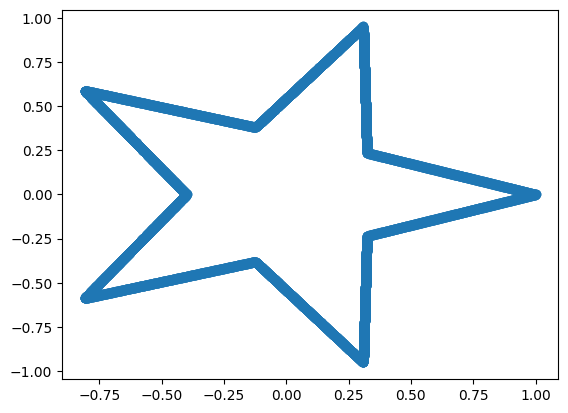

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [3]:
class Config:
    sigma_min = 0.01
    sigma_max = 4.0

    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

In [4]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [5]:
def sigma_t(t, config):
    return config.sigma_min * (config.sigma_max / config.sigma_min) ** t

def g_t(t, config):
    sigma = sigma_t(t, config)
    c = math.sqrt(2.0 * math.log(config.sigma_max / config.sigma_min))

    return sigma * c

In [6]:
class VETrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            sigma = sigma_t(t, self.config)

            z = torch.randn_like(batch)
            x_t = batch + sigma * z

            pred_z = self.model(x_t, t)
            # loss = ((sigma * pred_z + z) ** 2).sum(dim=1).mean()
            loss = F.mse_loss(pred_z, z)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            if n % 100 == 0:
                print(f'Loss: {loss}')

In [7]:
config = Config()
trainer = VETrainer(config)

In [8]:
trainer.run()

Loss: 0.8917871089935303
Loss: 0.634103528881073
Loss: 0.649851366519928
Loss: 0.6330676201820373
Loss: 0.6197169116973877
Loss: 0.6124349123954773
Loss: 0.6127071716308594
Loss: 0.5869611855506897
Loss: 0.5967887621879577
Loss: 0.5704643123626709
Loss: 0.5742293129920959
Loss: 0.571733385848999
Loss: 0.5789271969795227
Loss: 0.5634882822990418
Loss: 0.5834131655693054
Loss: 0.5653763554573059
Loss: 0.5683378938674927
Loss: 0.5637502661705017
Loss: 0.5626993163108825
Loss: 0.5461597474098205


In [9]:
def sample(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device) * config.sigma_max

        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            sigma = sigma_t(t_tensor, config)
            gt = g_t(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / sigma

            drift = (gt ** 2) * score * dt
            diffusion = gt * torch.randn_like(x) * math.sqrt(dt)

            x = x + drift + diffusion

        return x.cpu().numpy()

In [10]:
samples = sample(trainer.model, trainer.config, 1000)

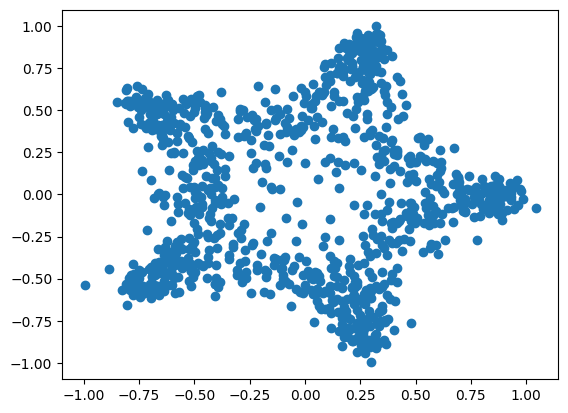

In [11]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

In [12]:
def get_alpha_bar_linear(t, b_min=0.1, b_max=20.0):
    return torch.clamp(torch.exp(-(b_min * t + 0.5 * (b_max - b_min) * t ** 2)), 1e-5, 1 - 1e-5)

def get_beta_linear(t, b_min=0.1, b_max=20.0):
    return b_min + (b_max - b_min) * t

def get_alpha_bar_cosine(t, offset=0.008):
    theta = (t + offset) / (1.0 + offset) * math.pi / 2
    norm = math.cos(offset / (1.0 + offset) * math.pi / 2) ** 2
    return torch.clamp(torch.cos(theta) ** 2 / norm, 1e-5, 1 - 1e-5)

def get_beta_cosine(t, offset=0.008, clip=20.0):
    theta = (t + offset) / (1.0 + offset) * math.pi / 2
    return torch.clamp(math.pi / (1.0 + offset) * torch.tan(theta), 1e-6, clip)

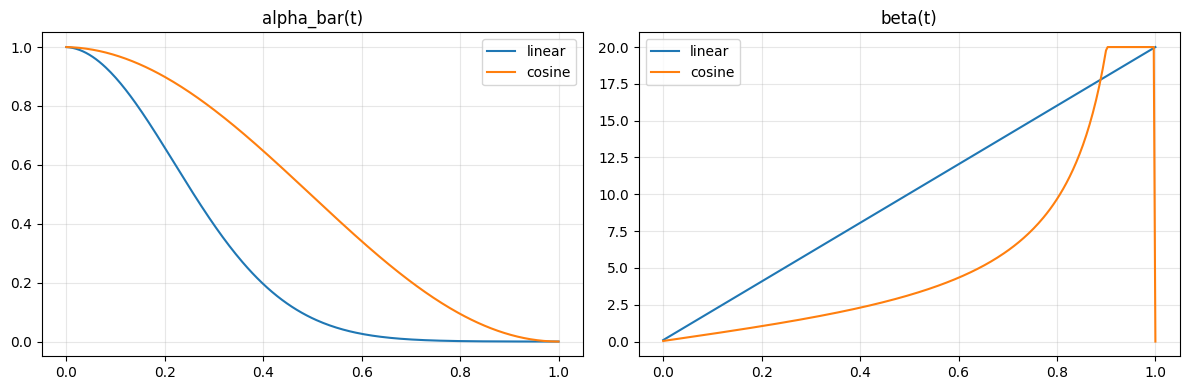

In [13]:
tt = torch.linspace(0, 1, 300)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(tt.numpy(), get_alpha_bar_linear(tt).numpy(), label='linear')
a1.plot(tt.numpy(), get_alpha_bar_cosine(tt).numpy(), label='cosine')
a1.set_title('alpha_bar(t)')
a1.legend()
a1.grid(True, alpha=0.3)

a2.plot(tt.numpy(), get_beta_linear(tt).numpy(), label='linear')
a2.plot(tt.numpy(), get_beta_cosine(tt).numpy(), label='cosine')
a2.set_title('beta(t)')
a2.legend()
a2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
def w_none(ab, b, t):
    return 1.0

def w_snr(ab, b, t):
    return torch.clamp(ab / (1.0 - ab + 1e-5), max=5.0)

def w_beta(ab, b, t):
    return b

In [15]:
def train_vp(ab_fn, b_fn, w_fn, cfg, n_epochs=2000):
    dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    star_data = torch.tensor(generate_star(n_samples=cfg.data_samples), dtype=torch.float32)
    loader = DataLoader(TensorDataset(star_data), batch_size=cfg.batch_size, shuffle=True)
    net = ScoreModel(cfg).to(dev)
    opt = optim.Adam(net.parameters(), lr=cfg.lr)
    hist = []
    for ep in range(n_epochs):
        net.train()
        ep_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(dev)
            t = torch.clamp(torch.rand(batch.shape[0], 1, device=dev), 1e-5, 1 - 1e-5)
            ab = ab_fn(t)
            noise = torch.randn_like(batch)
            noisy = torch.sqrt(ab) * batch + torch.sqrt(1 - ab) * noise
            pred = net(noisy, t)
            wt = w_fn(ab, b_fn(t), t)
            loss = (wt * (pred - noise) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
            ep_loss += loss.item() * batch.shape[0]
        hist.append(ep_loss / len(star_data))
        if ep % 500 == 0:
            print(f'  ep {ep}: {hist[-1]:.6f}')
    return net, hist

In [16]:
def generate_vp(net, ab_fn, b_fn, n=1000, steps=1000):
    dev = next(net.parameters()).device
    net.eval()
    with torch.no_grad():
        x = torch.randn(n, 2, device=dev)
        dt = 1.0 / steps
        for k in range(steps):
            tc = max(1.0 - k * dt, 1e-5)
            tv = torch.full((n, 1), tc, device=dev)
            ab = ab_fn(tv)
            bt = b_fn(tv)
            eps = net(x, tv)
            sc = -eps / torch.sqrt(1 - ab)
            x = x + (0.5 * bt * x + bt * sc) * dt
            if k < steps - 1:
                x = x + torch.sqrt(bt * dt) * torch.randn_like(x)
    return x.cpu().numpy()

In [17]:
schedule_fns = {
    'linear': (get_alpha_bar_linear, get_beta_linear),
    'cosine': (get_alpha_bar_cosine, get_beta_cosine),
}
weight_fns = {
    'uniform': w_none,
    'snr': w_snr,
    'likelihood': w_beta,
}

cfg = Config()
results = {}

for sk, (ab_f, b_f) in schedule_fns.items():
    for wk, w_f in weight_fns.items():
        tag = f'{sk}_{wk}'
        print(f'\n--- {tag} ---')
        mdl, losses = train_vp(ab_f, b_f, w_f, cfg)
        pts = generate_vp(mdl, ab_f, b_f, n=1000, steps=cfg.num_timesteps)
        results[tag] = {'losses': losses, 'samples': pts}
        print(f'  done, final loss = {losses[-1]:.6f}')


--- linear_uniform ---
  ep 0: 0.897975
  ep 500: 0.169487
  ep 1000: 0.155672
  ep 1500: 0.147781
  done, final loss = 0.156262

--- linear_snr ---
  ep 0: 1.061054
  ep 500: 0.590824
  ep 1000: 0.575957
  ep 1500: 0.554560
  done, final loss = 0.547030

--- linear_likelihood ---
  ep 0: 8.509727
  ep 500: 0.462670
  ep 1000: 0.447041
  ep 1500: 0.447229
  done, final loss = 0.447835

--- cosine_uniform ---
  ep 0: 0.921988
  ep 500: 0.301238
  ep 1000: 0.302353
  ep 1500: 0.287574
  done, final loss = 0.284394

--- cosine_snr ---
  ep 0: 1.898432
  ep 500: 1.207046
  ep 1000: 1.139535
  ep 1500: 1.166006
  done, final loss = 1.048630

--- cosine_likelihood ---
  ep 0: 4.920314
  ep 500: 0.451931
  ep 1000: 0.435019
  ep 1500: 0.451276
  done, final loss = 0.459927


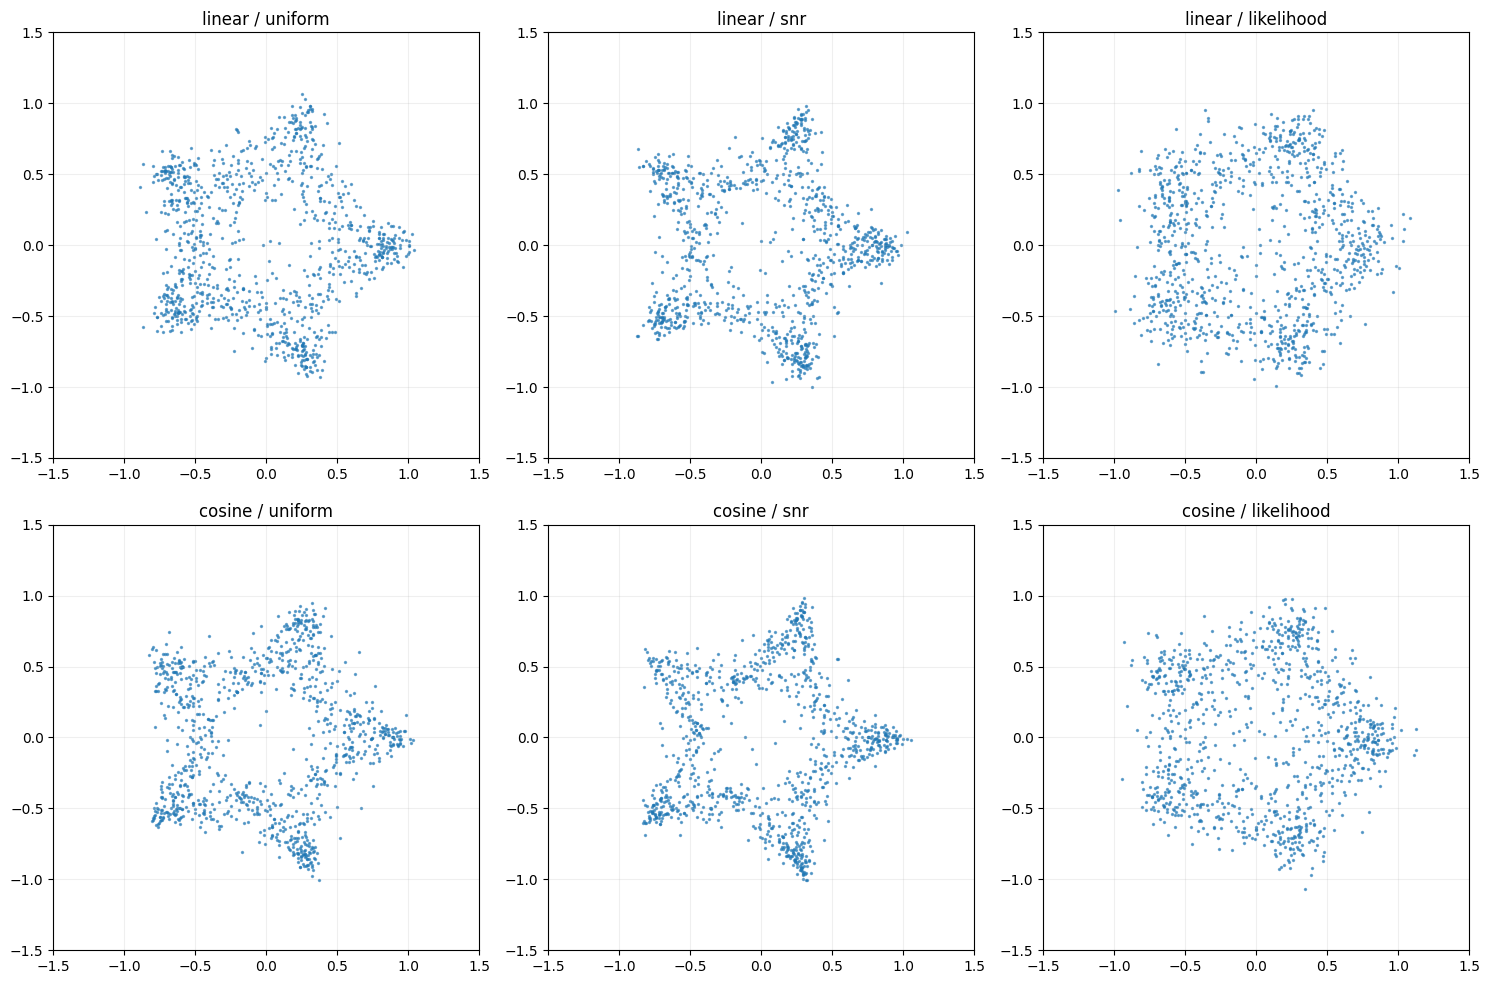

In [18]:
skeys = ['linear', 'cosine']
wkeys = ['uniform', 'snr', 'likelihood']

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for r, sk in enumerate(skeys):
    for c, wk in enumerate(wkeys):
        d = results[f'{sk}_{wk}']
        axs[r][c].scatter(d['samples'][:, 0], d['samples'][:, 1], s=2, alpha=0.6)
        axs[r][c].set_title(f'{sk} / {wk}')
        axs[r][c].set_xlim(-1.5, 1.5)
        axs[r][c].set_ylim(-1.5, 1.5)
        axs[r][c].set_aspect('equal')
        axs[r][c].grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

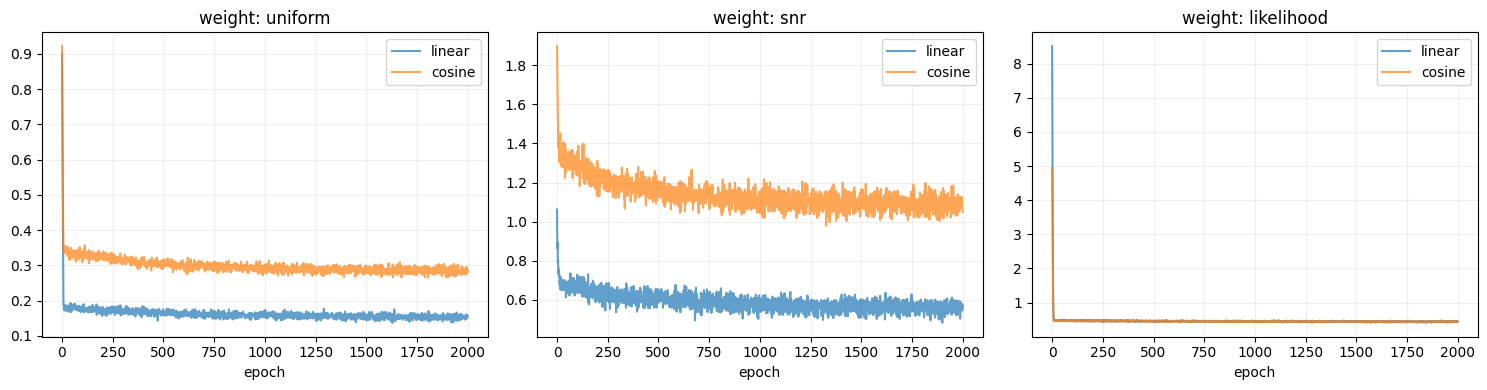

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for c, wk in enumerate(wkeys):
    for sk in skeys:
        axs[c].plot(results[f'{sk}_{wk}']['losses'], label=sk, alpha=0.7)
    axs[c].set_title(f'weight: {wk}')
    axs[c].set_xlabel('epoch')
    axs[c].legend()
    axs[c].grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

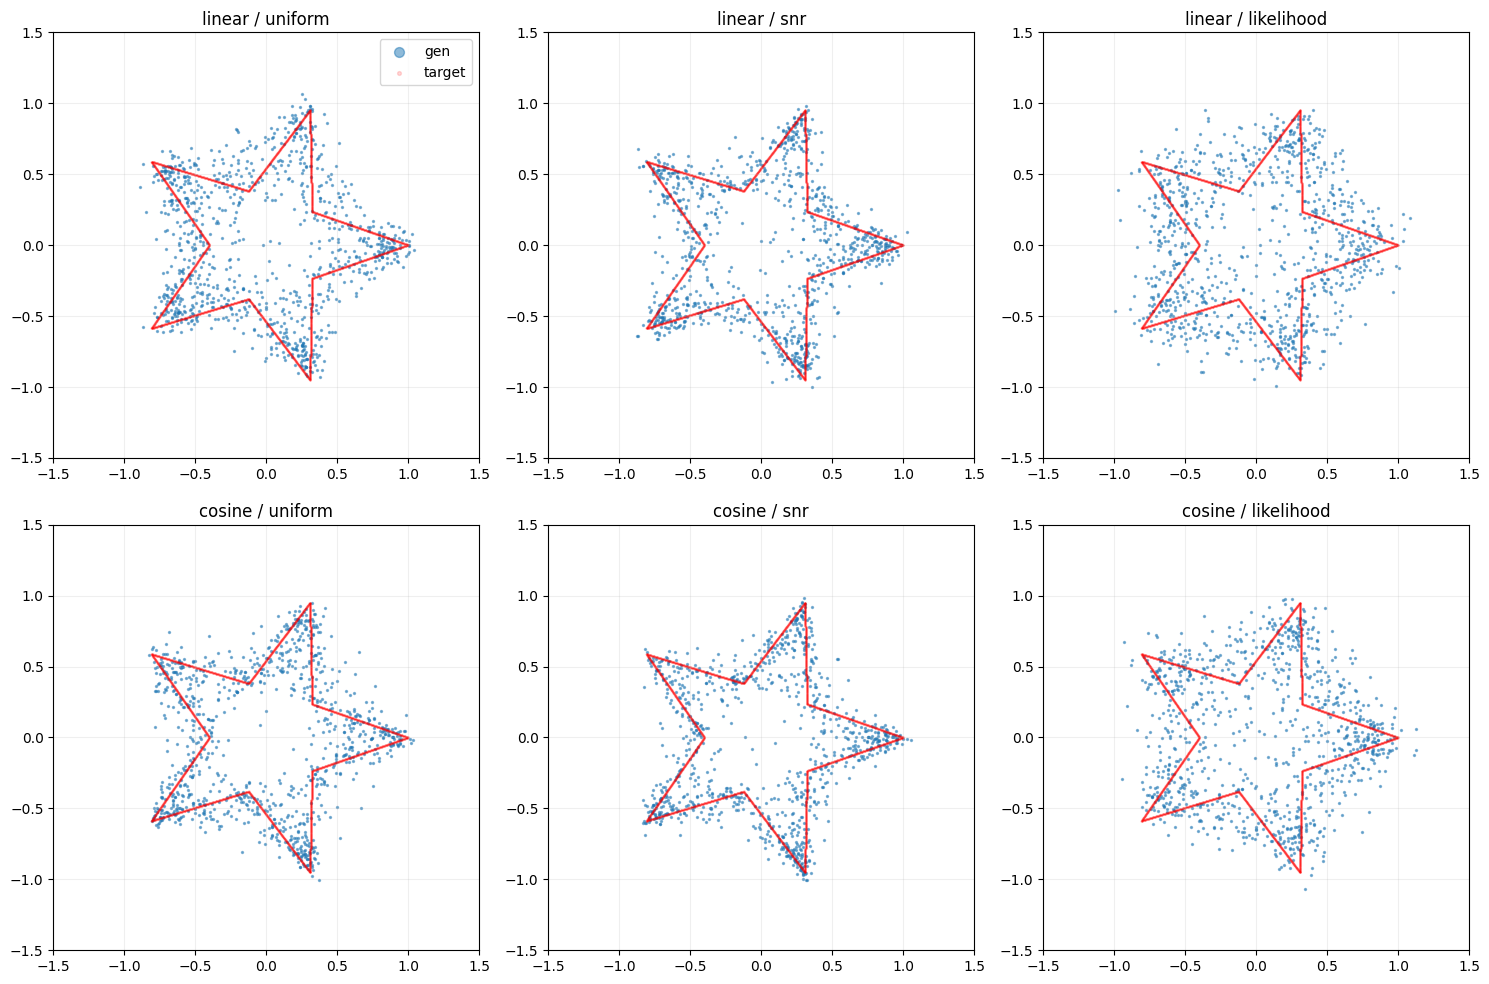

In [20]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for r, sk in enumerate(skeys):
    for c, wk in enumerate(wkeys):
        d = results[f'{sk}_{wk}']
        axs[r][c].scatter(d['samples'][:, 0], d['samples'][:, 1], s=2, alpha=0.5, label='gen')
        axs[r][c].scatter(s[:, 0], s[:, 1], s=0.3, alpha=0.15, c='red', label='target')
        axs[r][c].set_title(f'{sk} / {wk}')
        axs[r][c].set_xlim(-1.5, 1.5)
        axs[r][c].set_ylim(-1.5, 1.5)
        axs[r][c].set_aspect('equal')
        axs[r][c].grid(True, alpha=0.2)
        if r == 0 and c == 0:
            axs[r][c].legend(markerscale=5)
plt.tight_layout()
plt.show()

Косинусовое расписание дает более равномерное распределение информации по шкале времени, из-за чего модель лучше обучается на промежуточных уровнях шума и точнее воспроизводит тонкие детали звездочки вроде кончиков лучей.

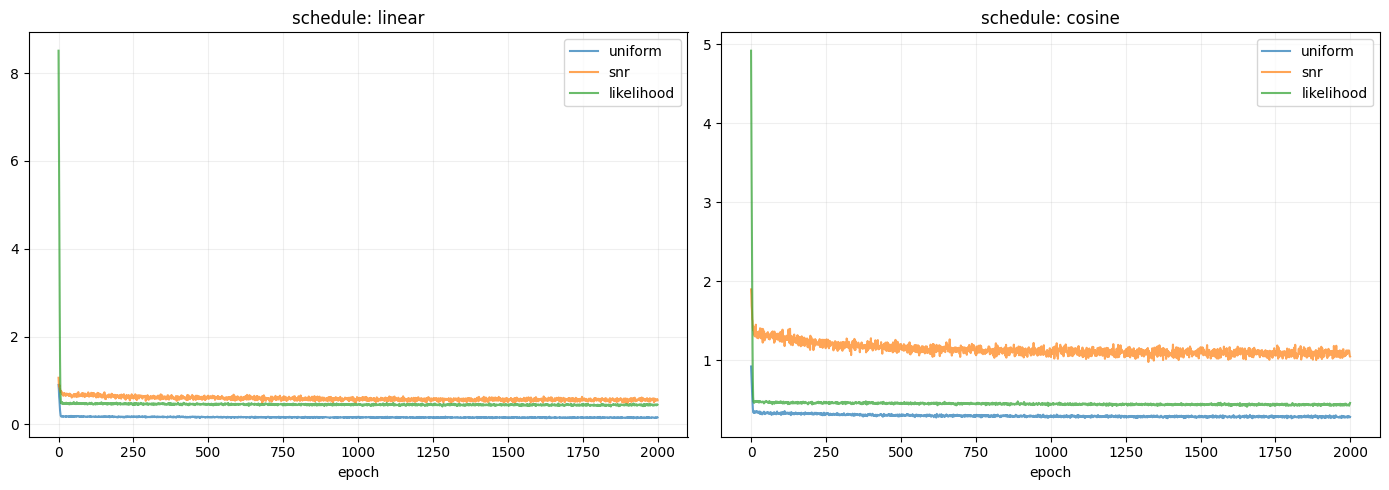

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for i, sk in enumerate(skeys):
    for wk in wkeys:
        axs[i].plot(results[f'{sk}_{wk}']['losses'], label=wk, alpha=0.7)
    axs[i].set_title(f'schedule: {sk}')
    axs[i].set_xlabel('epoch')
    axs[i].legend()
    axs[i].grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Равномерное взвешивание является надежным базовым выбором для двумерных данных, SNR-взвешивание с обрезкой улучшает детализацию за счет акцента на чистых сэмплах, а взвешивание через beta подчеркивает обучение на зашумленных примерах и лучше схватывает общую геометрию формы.

VP-SDE диффузия генерирует звездочку при всех шести конфигурациях, причем комбинация косинусового расписания с SNR-перевзвешиванием в большинстве случаев дает наиболее четкий и близкий к оригиналу результат. Линейное расписание тоже работоспособно, но из-за агрессивного роста шума в начале процесса уступает косинусовому по качеству мелких деталей.